Setup:

In [1]:
import gc
import torch

torch.cuda.empty_cache()
gc.collect()

torch.cuda.synchronize()
torch.cuda.reset_peak_memory_stats()

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM

tokenizer = AutoTokenizer.from_pretrained('meta-llama/Llama-2-7b-hf')
model = AutoModelForCausalLM.from_pretrained('meta-llama/Llama-2-7b-hf', device_map="auto")
model.seqlen = model.config.max_position_embeddings

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

In [3]:
# model.hf_device_map

from llm import find_layers

find_layers(model)

# length = 0
# for name, param in model.named_parameters():
#     if 'proj' in name:
#         print(name, param.shape)
#         length += 1
# print(f'Matrix count: {length}')

{'model.layers.0.self_attn.q_proj': Linear(in_features=4096, out_features=4096, bias=False),
 'model.layers.0.self_attn.k_proj': Linear(in_features=4096, out_features=4096, bias=False),
 'model.layers.0.self_attn.v_proj': Linear(in_features=4096, out_features=4096, bias=False),
 'model.layers.0.self_attn.o_proj': Linear(in_features=4096, out_features=4096, bias=False),
 'model.layers.0.mlp.gate_proj': Linear(in_features=4096, out_features=11008, bias=False),
 'model.layers.0.mlp.up_proj': Linear(in_features=4096, out_features=11008, bias=False),
 'model.layers.0.mlp.down_proj': Linear(in_features=11008, out_features=4096, bias=False),
 'model.layers.1.self_attn.q_proj': Linear(in_features=4096, out_features=4096, bias=False),
 'model.layers.1.self_attn.k_proj': Linear(in_features=4096, out_features=4096, bias=False),
 'model.layers.1.self_attn.v_proj': Linear(in_features=4096, out_features=4096, bias=False),
 'model.layers.1.self_attn.o_proj': Linear(in_features=4096, out_features=4096

Tests:

224

Currently pruning: model.layers.0.self_attn.q_proj


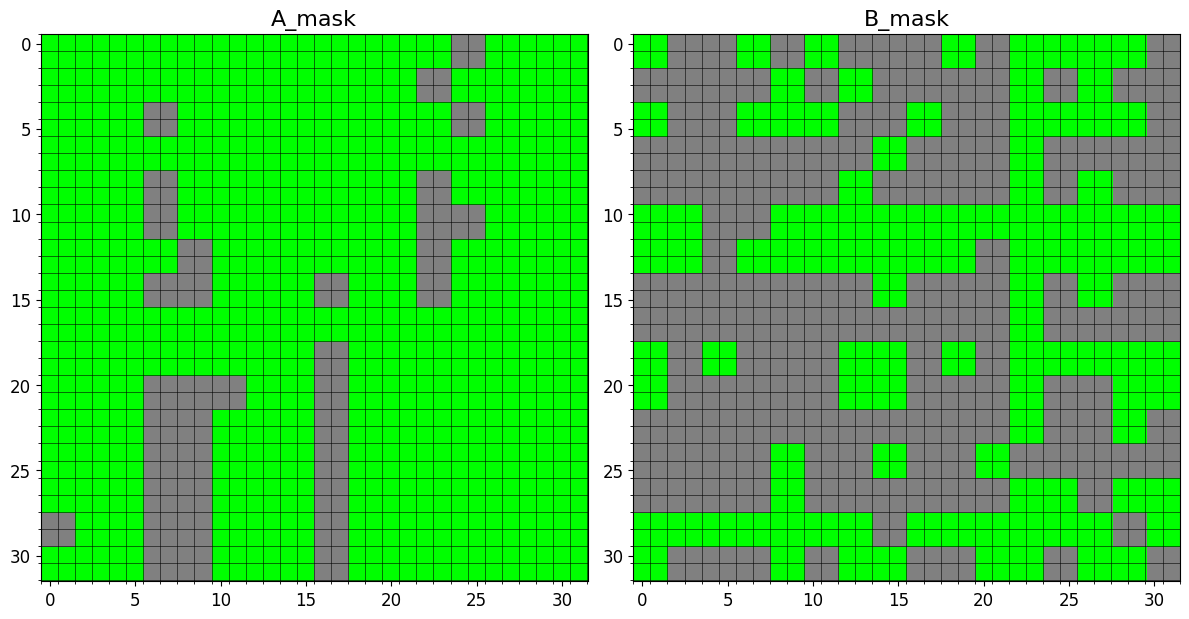

Frobenius norm: 2.1705195903778076
A has 4194304 non-zero entries (25.0%)
B has 4194304 non-zero entries (25.0%)

Currently pruning: model.layers.0.self_attn.k_proj


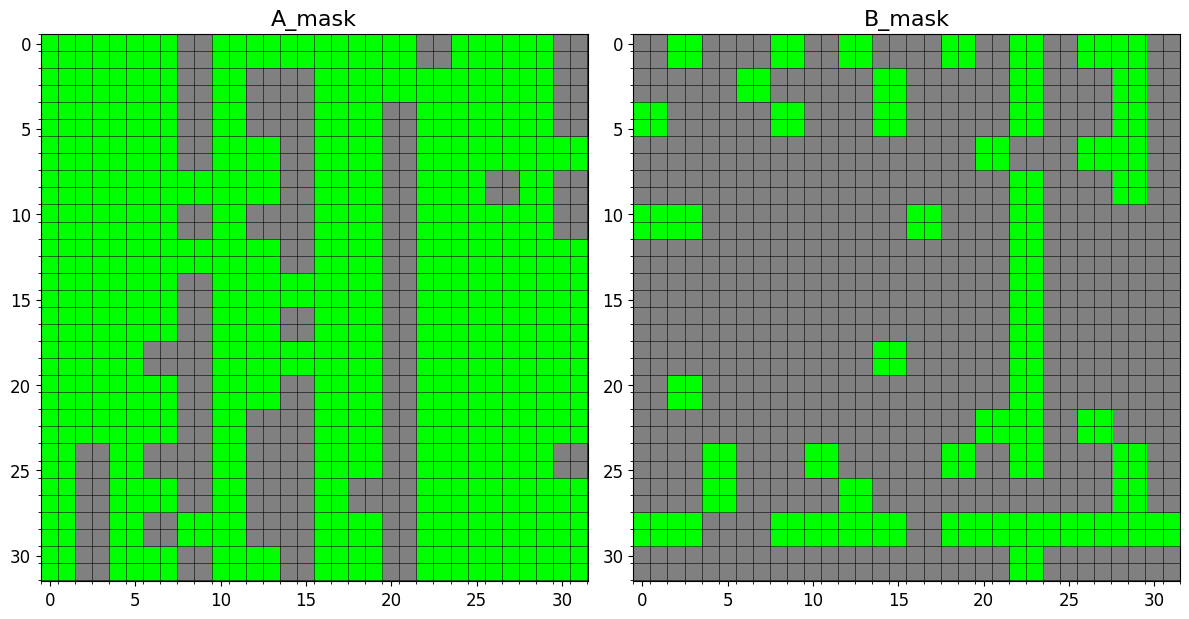

Frobenius norm: 2.2659547328948975
A has 4194304 non-zero entries (25.0%)
B has 4194304 non-zero entries (25.0%)

Currently pruning: model.layers.0.self_attn.v_proj


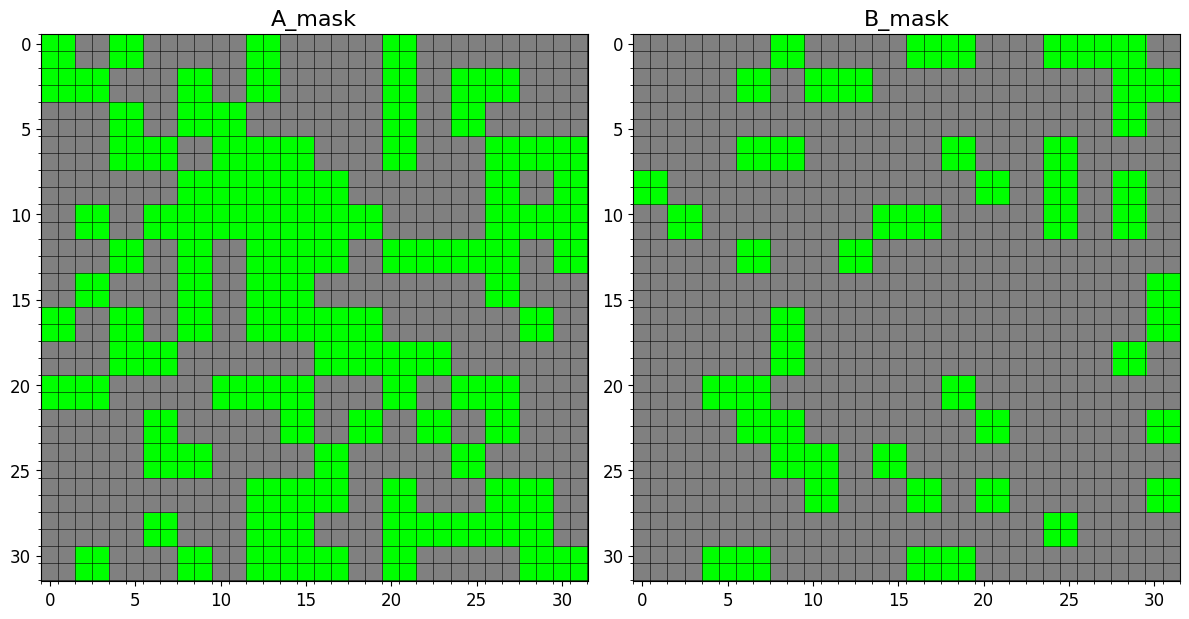

Frobenius norm: 10.043665885925293
A has 4194304 non-zero entries (25.0%)
B has 4194304 non-zero entries (25.0%)

Currently pruning: model.layers.0.self_attn.o_proj


KeyboardInterrupt: 

In [4]:
from llm import prune_model
prune_model(model)

Cleanup:

In [ ]:
import gc

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()